In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.cbook
import zipfile
import warnings

warnings.filterwarnings("ignore")

In [4]:
##  Load the Dataset

data = pd.read_csv("data/Indicators.bz2")

print("Dataset Shape:", data.shape)


Dataset Shape: (5656458, 6)


In [7]:
## Display Sample Data

data.head(10)

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,1.335609e+02
1,Arab World,ARB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,8.779760e+01
2,Arab World,ARB,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,6.634579e+00
3,Arab World,ARB,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,8.102333e+01
4,Arab World,ARB,Arms exports (SIPRI trend indicator values),MS.MIL.XPRT.KD,1960,3.000000e+06
5,Arab World,ARB,Arms imports (SIPRI trend indicator values),MS.MIL.MPRT.KD,1960,5.380000e+08
6,Arab World,ARB,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,1960,4.769789e+01
7,Arab World,ARB,CO2 emissions (kt),EN.ATM.CO2E.KT,1960,5.956399e+04
8,Arab World,ARB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,6.439635e-01
9,Arab World,ARB,CO2 emissions from gaseous fuel consumption (%...,EN.ATM.CO2E.GF.ZS,1960,5.041292e+00


In [8]:
## Explore Dataset Columns

print("Columns in Dataset:\n")
print(data.columns)

print("\nIndicator Names:\n")
print(data["IndicatorName"])

Columns in Dataset:

Index(['CountryName', 'CountryCode', 'IndicatorName', 'IndicatorCode', 'Year',
       'Value'],
      dtype='str')

Indicator Names:

0          Adolescent fertility rate (births per 1,000 wo...
1          Age dependency ratio (% of working-age populat...
2          Age dependency ratio, old (% of working-age po...
3          Age dependency ratio, young (% of working-age ...
4                Arms exports (SIPRI trend indicator values)
                                 ...                        
5656453            Time required to register property (days)
5656454             Time required to start a business (days)
5656455                Time to prepare and pay taxes (hours)
5656456                   Time to resolve insolvency (years)
5656457             Total tax rate (% of commercial profits)
Name: IndicatorName, Length: 5656458, dtype: str


In [6]:
## Explore Unique Values

countries = data["CountryName"].unique()
print("Total Countries :", len(countries))

country_codes = data["CountryCode"].unique()
print("Total Country Codes :", len(country_codes))

indicators = data["IndicatorName"].unique()
print("Total Indicators :", len(indicators))

years = data["Year"].unique()
print("Total Years :", len(years))

print("Year Range :", min(years), "to", max(years))

Total Countries : 247
Total Country Codes : 247
Total Indicators : 1344
Total Years : 56
Year Range : 1960 to 2015


In [11]:
## Filter CO₂ Emissions Data for USA

co2_indicator = "CO2 emissions \\(metric"
country = "USA"

mask1 = data["IndicatorName"].str.contains(co2_indicator)

mask2 = data["CountryCode"].str.contains(country)

co2_data = data[mask1 & mask2]

print("Filtered Data Shape :", co2_data.shape)

display(co2_data.head())

print("Indicator :", co2_data["IndicatorName"].iloc[0])

Filtered Data Shape : (52, 6)


,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
22232,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1960,15.999779
48708,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1961,15.681256
77087,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1962,16.013937
105704,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1963,16.482762
134742,United States,USA,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,1964,16.968119


Indicator : CO2 emissions (metric tons per capita)


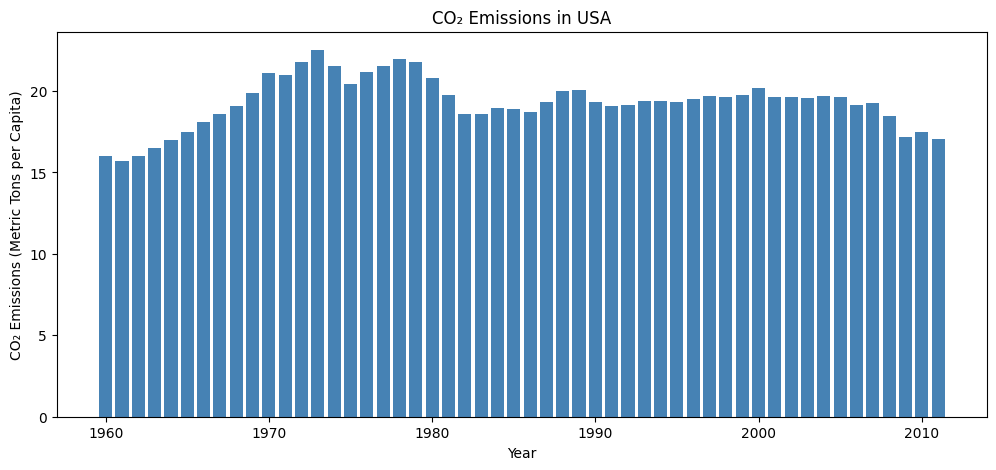

In [12]:
## Create a Bar Chart for CO₂ Emissions
## A line chart is used to better understand the trend of CO₂ emissions over different years.

years = co2_data["Year"].values
co2_values = co2_data["Value"].values

plt.figure(figsize=(12,5))
plt.bar(years, co2_values, color="steelblue")

plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Metric Tons per Capita)")
plt.title("CO₂ Emissions in USA")

plt.show()

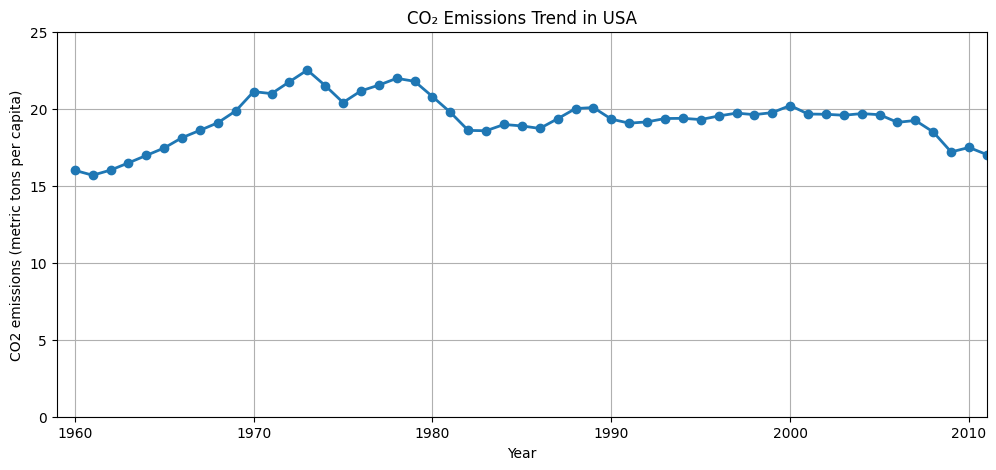

In [13]:
## Create a Line Chart
## The line chart clearly shows the trend of CO₂ emissions over time. It helps identify periods of increase and decrease in emission levels.

plt.figure(figsize=(12,5))

plt.plot(
    co2_data["Year"],
    co2_data["Value"],
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel(co2_data["IndicatorName"].iloc[0])

plt.title("CO₂ Emissions Trend in USA")

plt.axis([1959, 2011, 0, 25])

plt.grid(True)

plt.show()

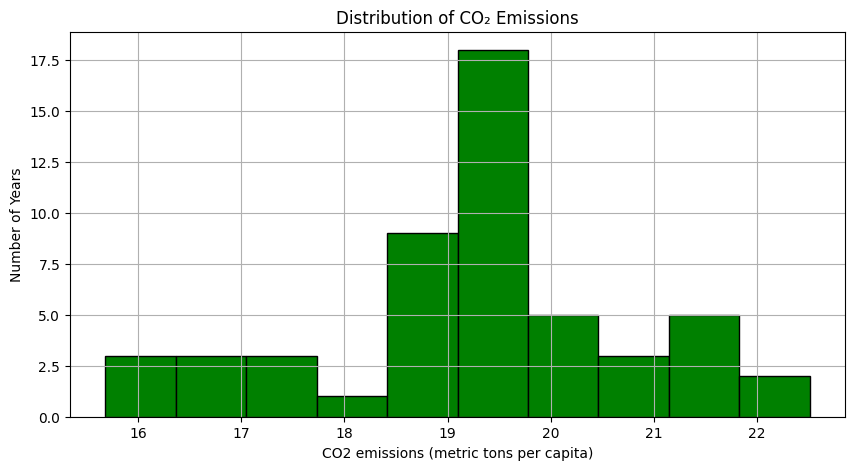

In [14]:
## Distribution of CO₂ Emissions

## The histogram shows how frequently different CO₂ emission values occur across the years.

hist_data = co2_data["Value"].values

plt.figure(figsize=(10,5))

plt.hist(
    hist_data,
    bins=10,
    color="green",
    edgecolor="black"
)

plt.xlabel(co2_data["IndicatorName"].iloc[0])

plt.ylabel("Number of Years")

plt.title("Distribution of CO₂ Emissions")

plt.grid(True)

plt.show()

In [15]:
##  Analyze CO₂ Emissions of All Countries (2011)

# ## In this step, CO₂ emission data for all countries in the year 2011 is extracted and visualized using a histogram.

co2_indicator = "CO2 emissions \\(metric"
selected_year = 2011

mask1 = data["IndicatorName"].str.contains(co2_indicator)
mask2 = data["Year"] == selected_year

co2_2011 = data[mask1 & mask2]

print("Total Countries in 2011:", len(co2_2011))

co2_2011.head()

Total Countries in 2011: 232


,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
5026275,Arab World,ARB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,4.724500
5026788,Caribbean small states,CSS,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,9.692960
5027295,Central Europe and the Baltics,CEB,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,6.911131
5027870,East Asia & Pacific (all income levels),EAS,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,5.859548
5028456,East Asia & Pacific (developing only),EAP,CO2 emissions (metric tons per capita),EN.ATM.CO2E.PC,2011,5.302499


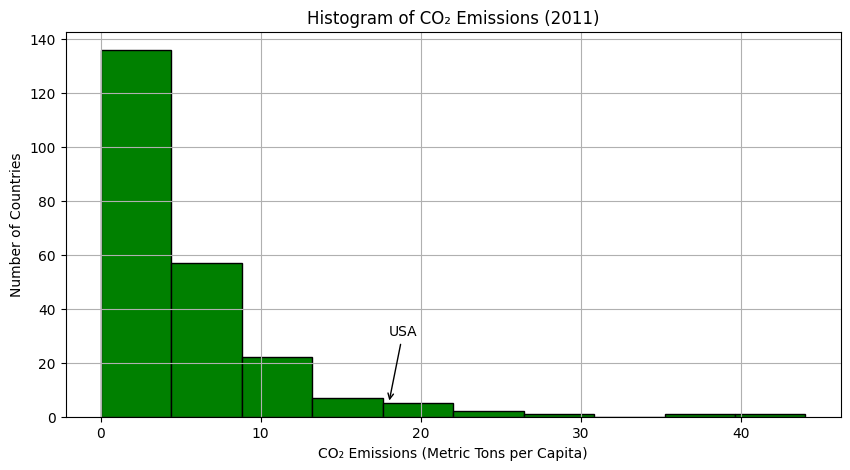

In [16]:
## Histogram of CO₂ Emissions (2011

This histogram shows the distribution of CO₂ emissions across all countries in 2011.

fig, ax = plt.subplots(figsize=(10,5))

ax.annotate(
    "USA",
    xy=(18,5),
    xycoords="data",
    xytext=(18,30),
    textcoords="data",
    arrowprops=dict(arrowstyle="->")
)

plt.hist(
    co2_2011["Value"],
    bins=10,
    color="green",
    edgecolor="black"
)

plt.xlabel("CO₂ Emissions (Metric Tons per Capita)")
plt.ylabel("Number of Countries")
plt.title("Histogram of CO₂ Emissions (2011)")

plt.grid(True)

plt.show()


In [17]:
##  Extract GDP per Capita Data (India)

### This histogram shows the distribution of CO₂ emissions across all countries in 2011.

gdp_indicator = "GDP per capita \\(constant 2005"
country = "IND"

mask1 = data["IndicatorName"].str.contains(gdp_indicator)
mask2 = data["CountryCode"].str.contains(country)

gdp_data = data[mask1 & mask2]

print("GDP Dataset Shape:", gdp_data.shape)

gdp_data.head()

GDP Dataset Shape: (55, 6)


,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
11616,India,IND,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1960,228.304470
36555,India,IND,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1961,232.142053
64095,India,IND,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1962,234.166685
92540,India,IND,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1963,243.176418
121337,India,IND,GDP per capita (constant 2005 US$),NY.GDP.PCAP.KD,1964,255.963668


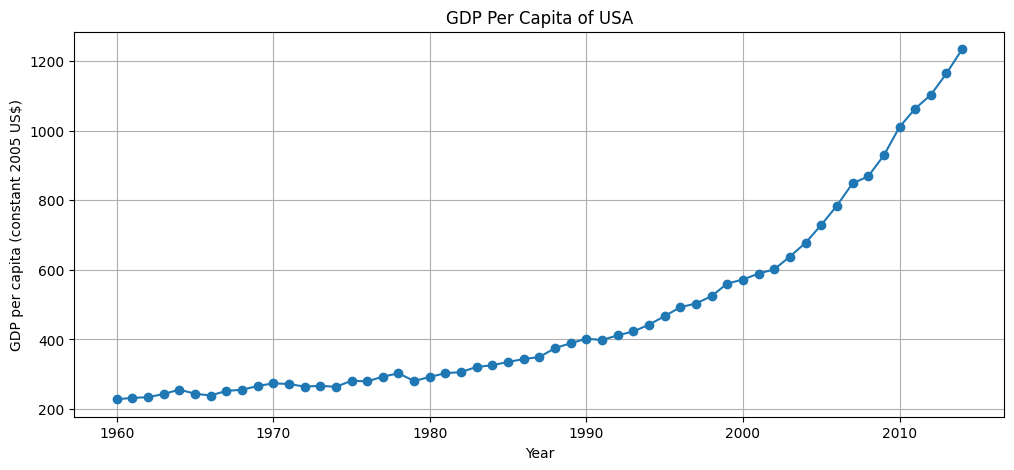

In [28]:
## GDP Trend Over Time

### The GDP per capita trend is visualized using a line chart.

plt.figure(figsize=(12,5))

plt.plot(
    gdp_data["Year"],
    gdp_data["Value"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel(gdp_data["IndicatorName"].iloc[0])

plt.title("GDP Per Capita of USA")

plt.grid(True)

plt.show()

In [19]:
## Compare Year Range

#### Before plotting the scatter graph, we check whether both datasets have the same year range.

print("GDP Minimum Year :", gdp_data["Year"].min())
print("GDP Maximum Year :", gdp_data["Year"].max())

print("CO₂ Minimum Year :", co2_data["Year"].min())
print("CO₂ Maximum Year :", co2_data["Year"].max())

GDP Minimum Year : 1960
GDP Maximum Year : 2014
CO₂ Minimum Year : 1960
CO₂ Maximum Year : 2011


In [20]:
## Prepare Data for Comparison

## The GDP dataset is trimmed so that both GDP and CO₂ datasets contain the same number of years.

gdp_trimmed = gdp_data[gdp_data["Year"] < 2012]

print("GDP Records :", len(gdp_trimmed))
print("CO₂ Records :", len(co2_data))

GDP Records : 52
CO₂ Records : 52


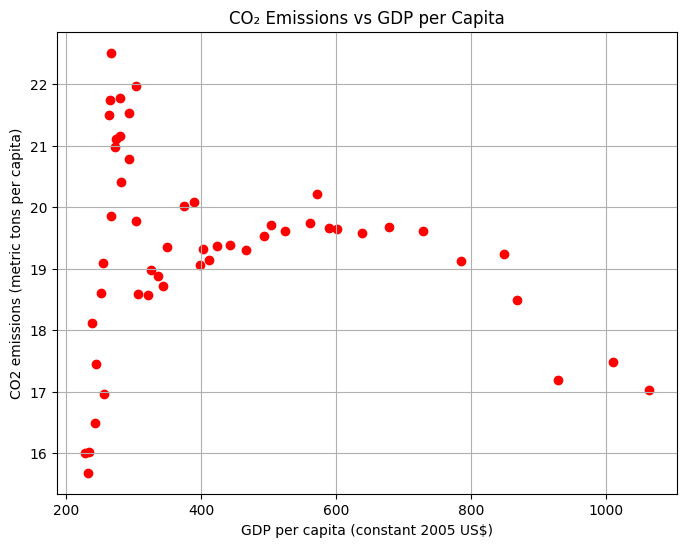

In [24]:
## Scatter Plot
### A scatter plot is used to study the relationship between GDP per capita and CO₂ emissions.

fig, ax = plt.subplots(figsize=(8,6))

ax.grid(True)

ax.set_title("CO₂ Emissions vs GDP per Capita")

ax.set_xlabel(gdp_trimmed["IndicatorName"].iloc[0])

ax.set_ylabel(co2_data["IndicatorName"].iloc[0])

ax.scatter(
    gdp_trimmed["Value"],
    co2_data["Value"],
    color="red"
)

plt.show()

In [25]:
## Correlation Analysis
### The correlation coefficient is calculated to measure the relationship between GDP per capita and CO₂ emissions.

correlation = np.corrcoef(
    gdp_trimmed["Value"],
    co2_data["Value"]
)

print("Correlation Matrix:\n")
print(correlation)

Correlation Matrix:

[[ 1.         -0.17779152]
 [-0.17779152  1.        ]]
